<a href="https://colab.research.google.com/github/ethanmachado2/CS271-FP-EthanMachado/blob/main/CS271_FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1 - Project foundation

## Data Acquisition

#### Ethan Machado
#### CS 271
#### March 29, 2026

* FOMC dataset with traditional sentiment labels is being sourced from here: [janspoerer/fomc](https://huggingface.co/datasets/janspoerer/fomc)
* FOMC datasets with hawkish/dovish sentiment labels are being sourced from here: https://github.com/gtfintechlab/fomc-hawkish-dovish

Loading both FOMC datasets (1 with traditional sentiment labels and 1 with hawkish/dovish labels), performing acquisition of S&P 500 data, removing unlabeled rows in both FOMC datasets, calculating 3-day S&P 500 directional movement feature, and merging the traditional sentiment label FOMC dataframe with the S&P 500 dataframe.

Note: The FOMC hawkish/dovish currently chosen for loading is the meeting minutes dataset. There are 2 additional datsets containing identical columns: 1 for speeches made by Fed officials, and 1 for press conferences held by Fed officials.

In [7]:
import pandas as pd
import yfinance as yf
from datetime import timedelta

try:
    # csv containing FOMC sentences with traditional positive/negative sentiment labels
    fomc_dated = pd.read_csv('/content/FOMC.csv')

    # csv containing FOMC sentences with dovish/hawkish sentiment labels to capture policy posture
    fomc_labeled = pd.read_csv('/content/manual-mm-split.csv')
    print("Files loaded successfully.")
except FileNotFoundError:
    print("Error: Files not loaded.")

# filter out the "-" labels from the dataset, as some records in the hawkish/dovish dataset are missing labels
fomc_labeled = fomc_labeled[fomc_labeled['label'] != '-'].copy()
# converting labels to int type
fomc_labeled['label'] = fomc_labeled['label'].astype(int)

# filter out the "No majority found" labels from the traditional sentiment labels dataset in the growth_sentiment column
fomc_dated = fomc_dated[fomc_dated['growth_sentiment'] != 'No majority found']

# map labels for the distribution summary
stance_map = {1: 'Hawkish', 0: 'Dovish', 2: 'Neutral'}
fomc_labeled['stance_name'] = fomc_labeled['label'].map(stance_map)

# obtaining S%P 500 market data
print("Downloading S&P 500 data")
spy = yf.download("SPY", start="2006-01-01", end="2025-01-01")
print("Downloaded S&P 500 data")

# flattening the headers of the SPY market dataset
# removes the 'SPY' sub-header and keeps just the top level header
if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)

# calculate 3-day directional movement of the S&P 500 (Close at T vs Close at T+3)
spy['3d_return'] = spy['Close'].pct_change(periods=3).shift(-3)
spy['target_direction'] = (spy['3d_return'] > 0).astype(int)

# merging datasets into single dataframe based on dates
# merged dataframe contains FOMC traditional label data along with S%P 500 3-day directional change feature
fomc_dated['date'] = pd.to_datetime(fomc_dated['date']).dt.date
spy_simple = spy[['target_direction']].reset_index()
spy_simple['Date'] = spy_simple['Date'].dt.date

master_df = pd.merge(fomc_dated, spy_simple, left_on='date', right_on='Date', how='inner')

Files loaded successfully.


/tmp/ipykernel_20663/4097480906.py:29: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download("SPY", start="2006-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed

Downloaded S&P 500 data


Simple exploratory data analysis performed on both FOMC dataframes, the S&P 500 dataframe, and the merged dataframe.

In [8]:
# print first 2 records of both FOMC datasets to get better understanding of data
print(fomc_dated.head(2))
print(fomc_labeled.head(2))
print(spy_simple.head(2))
print(master_df.head(2))

# display shape of dataframes
print(f"FOMC traditional labels dataset shape: {fomc_dated.shape}")
print(f"FOMC hawkish/dovish labels dataset shape: {fomc_labeled.shape}")
print(f"S&P 500 dataset shape: {spy_simple.shape}")
print(f"Merged dataset shape: {master_df.shape}")

# display info on dataframes
fomc_dated.info()
fomc_labeled.info()
spy_simple.info()
master_df.info()

        id        date                                           sentence  \
0  11901.0  2015-04-08  Imports rose in December, with an increased vo...   
1  11902.0  2015-04-08  Commercial and industrial loans on banks' book...   

   sentence_length growth_sentiment employment_sentiment inflation_sentiment  \
0               23          neutral              neutral             neutral   
1               21         positive              neutral             neutral   

  prediction_finbert  sentiment_score_finbert sentiment_vader_logit  \
0           negative                  -0.9400               neutral   
1           positive                   0.9351              positive   

   sentiment_vader_logit_score sentiment_vader_compound  \
0                     0.512897                 positive   
1                     0.666145                 positive   

   sentiment_vader_compound_score growth_sentiment_gpt4  \
0                          0.0516               neutral   
1                

Summary of data distribution provided below. As can be seen in the results for the FOMC traditional labels dataframe, employment sentiment and inflation sentiment labels are imbalanced (> 80% of records having a neutral label).

In [9]:
# Generating summary statistics to provide summary of data distribution as part of phase 1
print("\n" + "="*30)
print("PHASE 1: DATA DISTRIBUTION SUMMARY")
print("="*30)

# calculate and print distributions and counts of the three labels annotated by experts in the FOMC traditional dataframe
print(f"\n1. Sentiment Distribution (Traditional):")
print()
print(master_df['growth_sentiment'].value_counts(normalize=True) * 100)
print(master_df['growth_sentiment'].value_counts())
print()
print(master_df['employment_sentiment'].value_counts(normalize=True) * 100)
print(master_df['employment_sentiment'].value_counts())
print()
print(master_df['inflation_sentiment'].value_counts(normalize=True) * 100)
print(master_df['inflation_sentiment'].value_counts())

# calculate and print distributions and counts of the labels annotated by experts in the FOMC hawkish/dovish dataframe
print(f"\n2. Stance Distribution (Hawkish/Dovish):")
print(fomc_labeled['stance_name'].value_counts(normalize=True) * 100)

# calculate and print distributions and counts of the market directions from the S%P 500 dataset
print(f"\n3. Market Target Distribution (S&P 500 3-Day Move):")
# 1 = up, 0 = down
print(master_df['target_direction'].value_counts().rename({1: 'Market Up', 0: 'Market Down'}))
print(master_df['target_direction'].value_counts(normalize=True) * 100)


PHASE 1: DATA DISTRIBUTION SUMMARY

1. Sentiment Distribution (Traditional):

growth_sentiment
neutral     49.807692
positive    26.538462
negative    23.653846
Name: proportion, dtype: float64
growth_sentiment
neutral     518
positive    276
negative    246
Name: count, dtype: int64

employment_sentiment
neutral              87.692308
positive              6.250000
negative              5.384615
No majority found     0.673077
Name: proportion, dtype: float64
employment_sentiment
neutral              912
positive              65
negative              56
No majority found      7
Name: count, dtype: int64

inflation_sentiment
neutral              84.423077
positive              7.307692
negative              7.211538
No majority found     1.057692
Name: proportion, dtype: float64
inflation_sentiment
neutral              878
positive              76
negative              75
No majority found     11
Name: count, dtype: int64

2. Stance Distribution (Hawkish/Dovish):
stance_name
Neutral   

Saving the merged dataframe as a csv for later processing in future project phases.

In [10]:
# Save the final master dataset for later processing
master_df.to_csv('/content/fomc_market_master.csv', index=False)
print("\nSuccess: 'fomc_market_master.csv' created.")
fomc_labeled.to_csv('/content/fomc_labeled_df.csv', index=False)
print("\nSuccess: 'fomc_labeled_df.csv' created.")


Success: 'fomc_market_master.csv' created.

Success: 'fomc_labeled_df.csv' created.


# Phase 2 - Implementation & Baselines

#### Ethan Machado
#### CS 271
#### April 12, 2026

Classification baseline approach using logistic regression with Term Frequency-Inverse Document Frequency (TF-IDF) vectorization.
The code first vectorizes the sentences found in the dovish/hawkish dataset.
The code then trains a logistic regression model to predict a dovish/hawkish label for each sentence.
The code records the baseline approach's results such as Accuracy, F1-Score, and a confusion matrix.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

# --- RQ1 Baseline: Stance Classification ---
# Using the labeled dataset we cleaned earlier
X = fomc_labeled['sentence']
y = fomc_labeled['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tfidf = TfidfVectorizer(max_features=1000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

log_reg = LogisticRegression()
log_reg.fit(X_train_tfidf, y_train)
y_pred = log_reg.predict(X_test_tfidf)

print("RQ1 Baseline (Stance) Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

RQ1 Baseline (Stance) Accuracy: 0.6336633663366337
              precision    recall  f1-score   support

           0       0.67      0.54      0.60        59
           1       0.62      0.47      0.54        53
           2       0.62      0.79      0.70        90

    accuracy                           0.63       202
   macro avg       0.64      0.60      0.61       202
weighted avg       0.64      0.63      0.63       202



Prediction baseline approach using a majority class baseline.
The code calculates the accuracy of the prediction if a positive market direction label is chosen each time.
The code records the baseline approach's accuracy result.

In [12]:
# --- RQ2 Baseline: Market Prediction ---
# Majority Class Baseline
majority_guess = master_df['target_direction'].mode()[0]
baseline_acc = (master_df['target_direction'] == majority_guess).mean()
print(f"RQ2 Baseline (Majority Class) Accuracy: {baseline_acc:.4f}")

RQ2 Baseline (Majority Class) Accuracy: 0.6067


Additional prediction baseline approach using the VADER compound scores previously computed by Kim et al.
If the VADER compound score is > 0, then the code predicts the market direction to be positive. Else, the code predicts the market direction to be negative.
The code records the baseline approach's accuracy result.

In [13]:
# Predict Market Up (1) if VADER compound score is positive, else Down (0)
vader_preds = (master_df['sentiment_vader_compound_score'] > 0).astype(int)
vader_acc = (vader_preds == master_df['target_direction']).mean()
print(f"RQ2 Advanced Baseline (VADER Sentiment): {vader_acc:.4f}")

RQ2 Advanced Baseline (VADER Sentiment): 0.5058


Additional prediction baseline approach using a simple MLP that utilizes 3 generic sentiment labels previously computed by Kim et al. as features.
The MLP features 2 hidden layers with 100 and 50 neurons respectively. ReLU is used as the activation function.

In [14]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# 1. Select the tabular features (Sentiment Scores)
features = [
    'sentiment_score_finbert',
    'sentiment_vader_logit_score',
    'sentiment_vader_compound_score'
]

X = master_df[features]
y = master_df['target_direction']

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scaling (CRITICAL for MLPs)
# Neural networks are sensitive to the scale of input data.
# FinBERT is -1 to 1, but VADER might be different.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize the Simple MLP
# (100, 50) means two hidden layers with 100 and 50 neurons respectively
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=500,
    activation='relu',
    solver='adam',
    random_state=42
)

# 5. Train and Predict
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

print("RQ2 MLP Baseline Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

RQ2 MLP Baseline Accuracy: 0.6538461538461539
              precision    recall  f1-score   support

           0       0.59      0.13      0.22        75
           1       0.66      0.95      0.78       133

    accuracy                           0.65       208
   macro avg       0.62      0.54      0.50       208
weighted avg       0.63      0.65      0.58       208



Additional prediction baseline approach using a simple MLP that utilizes 3 generic sentiment labels previously computed by Kim et al. as features.
The MLP features 2 hidden layers with 100 and 50 neurons respectively. ReLU is used as the activation function. Learning rate = 0.001. Early stopping is enabled, which allows the model to stop training if validation loss does not improve after 10 epochs.

Iteration 1, loss = 0.69277968
Validation score: 0.595238
Iteration 2, loss = 0.68024040
Validation score: 0.595238
Iteration 3, loss = 0.67582211
Validation score: 0.595238
Iteration 4, loss = 0.67435814
Validation score: 0.595238
Iteration 5, loss = 0.67265206
Validation score: 0.595238
Iteration 6, loss = 0.67279902
Validation score: 0.595238
Iteration 7, loss = 0.67280840
Validation score: 0.595238
Iteration 8, loss = 0.67205300
Validation score: 0.595238
Iteration 9, loss = 0.67145355
Validation score: 0.595238
Iteration 10, loss = 0.67118191
Validation score: 0.595238
Iteration 11, loss = 0.67096046
Validation score: 0.595238
Iteration 12, loss = 0.67076669
Validation score: 0.595238
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.

Training complete after 12 epochs.
Final Training Loss: 0.6708
Final Validation Score (Accuracy): 0.5952


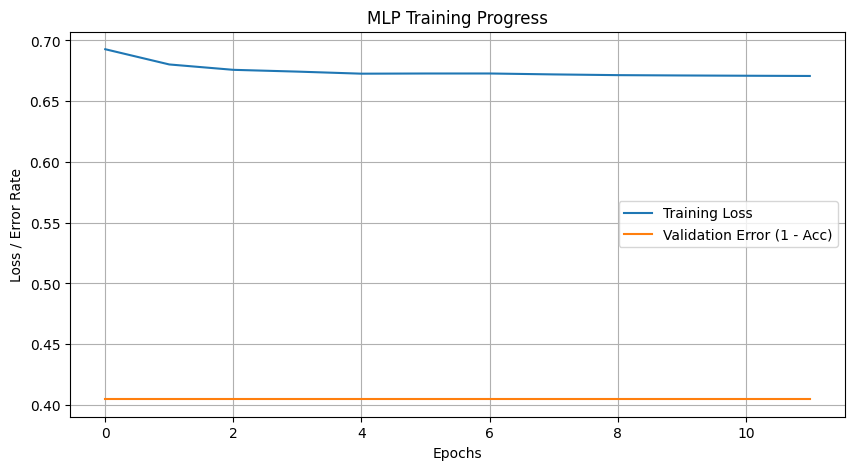

In [15]:
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Prepare Features and Target
features = ['sentiment_score_finbert', 'sentiment_vader_logit_score', 'sentiment_vader_compound_score']
X = master_df[features]
y = master_df['target_direction']

# 2. Split into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize MLP with Validation Tracking
# early_stopping=True automatically creates a validation set from the training data
mlp_enhanced = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=500,
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    early_stopping=True,      # This enables validation loss tracking
    validation_fraction=0.1,  # Uses 10% of training data for validation
    verbose=True,             # Prints loss for each epoch/iteration
    random_state=42
)

# 5. Train the model
mlp_enhanced.fit(X_train_scaled, y_train)

# --- DISPLAY METRICS ---

print(f"\nTraining complete after {mlp_enhanced.n_iter_} epochs.")
print(f"Final Training Loss: {mlp_enhanced.loss_:.4f}")
print(f"Final Validation Score (Accuracy): {mlp_enhanced.best_validation_score_:.4f}")

# 6. Plot the Loss Curve
plt.figure(figsize=(10, 5))
plt.plot(mlp_enhanced.loss_curve_, label='Training Loss')
if mlp_enhanced.validation_scores_ is not None:
    # Validation scores are stored as accuracy; we convert to 1-accuracy to mimic 'loss'
    val_loss_approx = [1 - x for x in mlp_enhanced.validation_scores_]
    plt.plot(val_loss_approx, label='Validation Error (1 - Acc)')

plt.title('MLP Training Progress')
plt.xlabel('Epochs')
plt.ylabel('Loss / Error Rate')
plt.legend()
plt.grid(True)
plt.show()

# Phase 3 - Methodology and Experiment Logs

#### Ethan Machado
#### CS 271
#### May 03, 2026

Using Groq for LLM reference. The first few code snippets are used to get an idea of the Groq API and available LLM models.

In [16]:

from openai import OpenAI
from google.colab import userdata

groq_api = userdata.get('GROQ_API_KEY')

client = OpenAI(
    api_key=groq_api,
    base_url="https://api.groq.com/openai/v1",
)

response = client.responses.create(
    input="Explain the importance of fast language models",
    model="openai/gpt-oss-20b",
)
print(response.output_text)

## Why “Fast” Language Models Matter

In the world of large language models (LLMs), *speed* is as crucial as *accuracy*.  
From the perspective of users, developers, businesses, and the planet itself, faster models unlock benefits that go far beyond a mere brag‑worthy latency number.

Below, we unpack the importance of speed in three dimensions:

1. **User Experience & Product Viability**  
2. **Operational Cost, Scalability, and Sustainability**  
3. **Research, Development, and Innovation**

---

### 1. User Experience & Product Viability

| Context | What speed enables | Why it matters |
|---------|--------------------|----------------|
| **Real‑time chat & assistants** | Sub‑100 ms per token (or < 200 ms overall) | Keeps conversations fluid; avoids “thinking” pauses that break the illusion of a living agent |
| **Voice & video interactions** | Latency < 50 ms (audio) or < 200 ms (video) | Critical for speech‑to‑text, real‑time translation, or captioning where delay is noticeable |


API used return available LLM models via Groq.

In [17]:
import requests
from google.colab import userdata

groq_api = userdata.get('GROQ_API_KEY')
url = "https://api.groq.com/openai/v1/models"

headers = {
    "Authorization": f"Bearer {groq_api}",
    "Content-Type": "application/json"
}

response = requests.get(url, headers=headers)

print(response.json())

{'object': 'list', 'data': [{'id': 'openai/gpt-oss-120b', 'object': 'model', 'created': 1754408224, 'owned_by': 'OpenAI', 'active': True, 'context_window': 131072, 'public_apps': None, 'max_completion_tokens': 65536}, {'id': 'canopylabs/orpheus-v1-english', 'object': 'model', 'created': 1766186316, 'owned_by': 'Canopy Labs', 'active': True, 'context_window': 4000, 'public_apps': None, 'max_completion_tokens': 50000}, {'id': 'openai/gpt-oss-safeguard-20b', 'object': 'model', 'created': 1761708789, 'owned_by': 'OpenAI', 'active': True, 'context_window': 131072, 'public_apps': None, 'max_completion_tokens': 65536}, {'id': 'openai/gpt-oss-20b', 'object': 'model', 'created': 1754407957, 'owned_by': 'OpenAI', 'active': True, 'context_window': 131072, 'public_apps': None, 'max_completion_tokens': 65536}, {'id': 'groq/compound', 'object': 'model', 'created': 1756949530, 'owned_by': 'Groq', 'active': True, 'context_window': 131072, 'public_apps': None, 'max_completion_tokens': 8192}, {'id': 'me

Reading both csv files in preparation for LLM hawkish/dovish stance labeling inference pipeline approach.

In [18]:
!pip install Groq
import os
import re
from groq import Groq
import pandas as pd
import numpy as np

master_df = pd.read_csv('/content/fomc_market_master.csv')
fomc_labeled_df = pd.read_csv('/content/fomc_labeled_df.csv')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.1 MB/s eta 0:00:00


In [19]:
# master_df = pd.read_csv('/content/fomc_market_master.csv')
master_df.head(3)

# Initialize client
client = Groq(api_key=groq_api)

def get_stance_llm_few_shot(sentence):
    # 1. Define your domain-specific examples (from manual-mm-split.csv)
    # It is best to choose 1 Hawkish, 1 Dovish, and 1 Neutral example.
    few_shot_messages = [
        {"role": "system", "content": "You are a specialized central bank economist. Classify FOMC sentences as: 1 (Hawkish), 0 (Dovish), or 2 (Neutral). Output ONLY the integer."},

        # Example 1: Hawkish (Inflation concern)
        {"role": "user", "content": "Sentence: A discernable upcreep was apparent in survey measures of short- and, to a limited extent, long-term inflation expectations over recent months."},
        {"role": "assistant", "content": "1"},

        # Example 2: Dovish (Growth concern / Easing)
        {"role": "user", "content": "Sentence: A more robust contour for final sales over the forecast horizon would lead to somewhat greater pressure on resource margins, despite the expected strong growth of structural productivity, though the level of activity would remain below the economy's potential for some time."},
        {"role": "assistant", "content": "0"},

        # Example 3: Neutral (Procedural / Balance)
        {"role": "user", "content": "Sentence: Both of these views would suggest a lower level of potential output and thus reduced scope for combating unemployment with additional monetary policy stimulus."},
        {"role": "assistant", "content": "2"},

        # The actual task
        {"role": "user", "content": f"Sentence: {sentence}"}
    ]

    try:
        chat_completion = client.chat.completions.create(
            messages=few_shot_messages,
            model="llama-3.3-70b-versatile",
            temperature=0,  # CRITICAL: Keep at 0 for research consistency
            max_tokens=5    # Stop the model from rambling
        )

        raw_output = chat_completion.choices[0].message.content.strip()

        # 2. Robust Parsing: Find the first digit in the response
        match = re.search(r'[0-2]', raw_output)
        if match:
            return int(match.group())
        return 2 # Default to Neutral if output is garbled

    except Exception as e:
        print(f"Error processing sentence: {e}")
        return 2

    # Test it on a small sample of your master_df
sample_df = master_df.head(5).copy()
sample_df['llm_stance'] = sample_df['sentence'].apply(get_stance_llm_few_shot)
print(sample_df[['sentence', 'llm_stance']])

                                            sentence  llm_stance
0  Imports rose in December, with an increased vo...           2
1  Commercial and industrial loans on banks' book...           1
2  Measures of residential mortgage lending condi...           0
3  Most participants judged that the conditions f...           0
4  Many members thought that labor market underut...           1


LLM (Llama 3.3-70b-versatile) is labeling validation data...
Error processing sentence: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kp6n4wptev89m36xbfvnv5ep` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99910, Requested 267. Please try again in 2m32.928s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}
Error processing sentence: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kp6n4wptev89m36xbfvnv5ep` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99910, Requested 257. Please try again in 2m24.288s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}
Error processing sentence: Error code: 429 - {'error': {'message': 'R

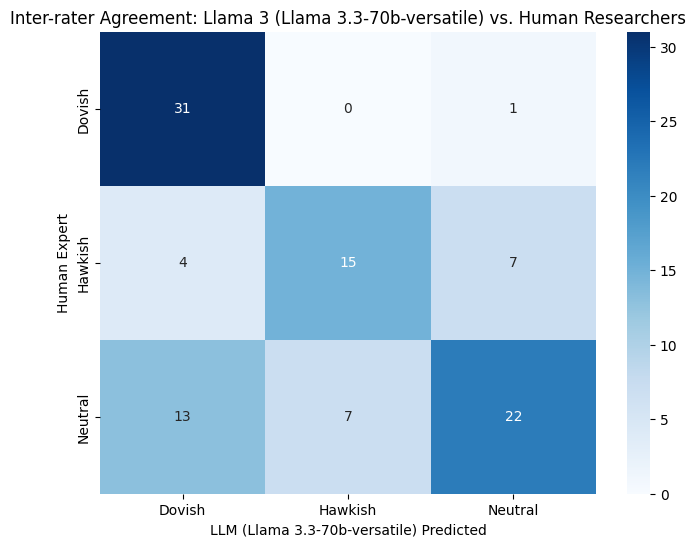

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Take a representative sample (e.g., 100 rows) to save on API time/limits
# Or run on the full 'fomc_labeled' if your rate limits allow
validation_df = fomc_labeled_df.sample(100, random_state=42).copy()

print("LLM (Llama 3.3-70b-versatile) is labeling validation data...")
validation_df['llm_label'] = validation_df['sentence'].apply(get_stance_llm_few_shot)

# 2. Generate Metrics
accuracy = accuracy_score(validation_df['label'], validation_df['llm_label'])
print(f"\nLLM vs. Human Accuracy: {accuracy:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(validation_df['label'], validation_df['llm_label'],
                          target_names=['Dovish (0)', 'Hawkish (1)', 'Neutral (2)']))

# 3. Visualize with a Confusion Matrix
cm = confusion_matrix(validation_df['label'], validation_df['llm_label'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dovish', 'Hawkish', 'Neutral'],
            yticklabels=['Dovish', 'Hawkish', 'Neutral'])
plt.xlabel('LLM (Llama 3.3-70b-versatile) Predicted')
plt.ylabel('Human Expert')
plt.title('Inter-rater Agreement: Llama 3 (Llama 3.3-70b-versatile) vs. Human Researchers')
plt.show()

In [21]:
!pip install -q transformers peft accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.9 MB/s eta 0:00:00


In [22]:
# Run this in a Colab cell to delete the model cache
!rm -rf /root/.cache/huggingface/hub

In [23]:
# 1. Install the hub library
!pip install -q huggingface_hub

# 2. Log in (this will prompt you to paste your token)
from huggingface_hub import login
login()

Token has not been saved to git credential helper.


In [24]:
# master_df = pd.read_csv('/content/fomc_market_master.csv')
master_df.head(3)

# Initialize client
client = Groq(api_key=groq_api)

def get_stance_llm_few_shot2(sentence):
    # 1. Define your domain-specific examples (from manual-mm-split.csv)
    # It is best to choose 1 Hawkish, 1 Dovish, and 1 Neutral example.
    few_shot_messages = [
        {"role": "system", "content": "You are a specialized central bank economist. Classify FOMC sentences as: 1 (Hawkish), 0 (Dovish), or 2 (Neutral). Output ONLY the integer."},

        # Example 1: Hawkish (Inflation concern)
        {"role": "user", "content": "Sentence: A discernable upcreep was apparent in survey measures of short- and, to a limited extent, long-term inflation expectations over recent months."},
        {"role": "assistant", "content": "1"},

        # Example 2: Dovish (Growth concern / Easing)
        {"role": "user", "content": "Sentence: A more robust contour for final sales over the forecast horizon would lead to somewhat greater pressure on resource margins, despite the expected strong growth of structural productivity, though the level of activity would remain below the economy's potential for some time."},
        {"role": "assistant", "content": "0"},

        # Example 3: Neutral (Procedural / Balance)
        {"role": "user", "content": "Sentence: Both of these views would suggest a lower level of potential output and thus reduced scope for combating unemployment with additional monetary policy stimulus."},
        {"role": "assistant", "content": "2"},

        # The actual task
        {"role": "user", "content": f"Sentence: {sentence}"}
    ]

    try:
        chat_completion = client.chat.completions.create(
            messages=few_shot_messages,
            model="llama-3.1-8b-instant",
            temperature=0,  # CRITICAL: Keep at 0 for research consistency
            max_tokens=5    # Stop the model from rambling
        )

        raw_output = chat_completion.choices[0].message.content.strip()

        # 2. Robust Parsing: Find the first digit in the response
        match = re.search(r'[0-2]', raw_output)
        if match:
            return int(match.group())
        return 2 # Default to Neutral if output is garbled

    except Exception as e:
        print(f"Error processing sentence: {e}")
        return 2

    # Test it on a small sample of your master_df
sample_df = master_df.head(5).copy()
sample_df['llm_stance'] = sample_df['sentence'].apply(get_stance_llm_few_shot2)
print(sample_df[['sentence', 'llm_stance']])

                                            sentence  llm_stance
0  Imports rose in December, with an increased vo...           2
1  Commercial and industrial loans on banks' book...           2
2  Measures of residential mortgage lending condi...           2
3  Most participants judged that the conditions f...           0
4  Many members thought that labor market underut...           2


LLM (Llama 3.1-8b-instant) is labeling validation data...

LLM vs. Human Accuracy: 0.6500

Detailed Classification Report:
              precision    recall  f1-score   support

  Dovish (0)       0.75      0.56      0.64        32
 Hawkish (1)       0.70      0.54      0.61        26
 Neutral (2)       0.59      0.79      0.67        42

    accuracy                           0.65       100
   macro avg       0.68      0.63      0.64       100
weighted avg       0.67      0.65      0.65       100



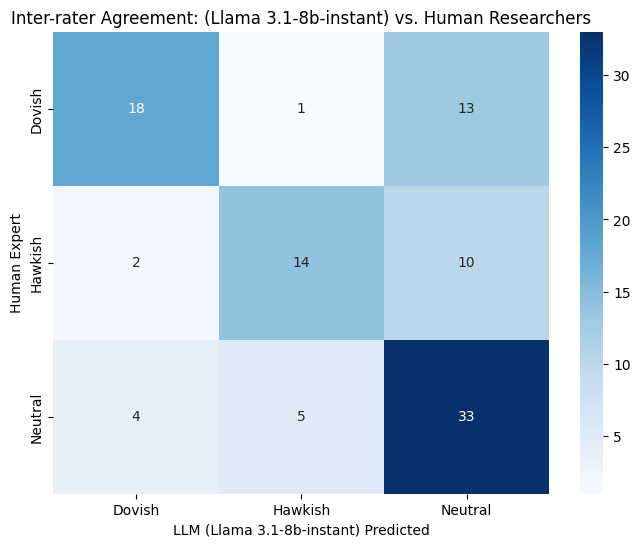

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Take a representative sample (e.g., 100 rows) to save on API time/limits
# Or run on the full 'fomc_labeled' if your rate limits allow
validation_df = fomc_labeled_df.sample(100, random_state=42).copy()

print("LLM (Llama 3.1-8b-instant) is labeling validation data...")
validation_df['llm_label'] = validation_df['sentence'].apply(get_stance_llm_few_shot2)

# 2. Generate Metrics
accuracy = accuracy_score(validation_df['label'], validation_df['llm_label'])
print(f"\nLLM vs. Human Accuracy: {accuracy:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(validation_df['label'], validation_df['llm_label'],
                          target_names=['Dovish (0)', 'Hawkish (1)', 'Neutral (2)']))

# 3. Visualize with a Confusion Matrix
cm = confusion_matrix(validation_df['label'], validation_df['llm_label'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dovish', 'Hawkish', 'Neutral'],
            yticklabels=['Dovish', 'Hawkish', 'Neutral'])
plt.xlabel('LLM (Llama 3.1-8b-instant) Predicted')
plt.ylabel('Human Expert')
plt.title('Inter-rater Agreement: (Llama 3.1-8b-instant) vs. Human Researchers')
plt.show()

# Revised Pipeline - Event-Level Market Prediction

The cells below replace the sentence-level RQ2 setup with the revised pipeline:

1. Generate sentence-level hawkish/dovish/neutral labels on `FOMC.xlsx` using the best validated stance model.
2. Aggregate sentence-level generic sentiment and domain-specific stance to the **FOMC event date**.
3. Attach the **3-trading-day forward SPY direction** to each event date.
4. Optionally add macro controls (CPI YoY and unemployment).
5. Evaluate simple, time-aware downstream models at the **event level**.

These cells can coexist with the earlier work, but the results from this section should be the ones used for the final paper's revised RQ2.

Evaluation of different models in the dovish/hawkish stance evaluation:

*   TF-IDF + Logistic Regression
*   FinBERT
*   FinBERT-FOMC
*   GPT
*   Llama





Evaluation of TF-IDF + Logistic Regression.

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

# --- RQ1 Baseline: Stance Classification ---
# Using the labeled dataset we cleaned earlier
X = fomc_labeled['sentence']
y = fomc_labeled['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tfidf = TfidfVectorizer(max_features=1000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

log_reg = LogisticRegression()
log_reg.fit(X_train_tfidf, y_train)
y_pred = log_reg.predict(X_test_tfidf)

print("RQ1 Baseline (Stance) Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

RQ1 Baseline (Stance) Accuracy: 0.6336633663366337
              precision    recall  f1-score   support

           0       0.67      0.54      0.60        59
           1       0.62      0.47      0.54        53
           2       0.62      0.79      0.70        90

    accuracy                           0.63       202
   macro avg       0.64      0.60      0.61       202
weighted avg       0.64      0.63      0.63       202



Evaluation of FinBERT.

In [27]:
!pip install -q transformers datasets accelerate openpyxl scikit-learn

In [28]:
import os
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

In [29]:
manual_path = "/content/manual-mm-split.csv"
manual_df = pd.read_csv(manual_path)

print(manual_df.head())
print(manual_df.columns)
print(manual_df["label"].value_counts(dropna=False))

   id com_type                                           sentence  year label  \
0   0       mm  "The Federal Open Market Committee seeks monet...  2011     2   
1   1       mm  1 The longer-run projections represent each pa...  2011     2   
2   2       mm  A couple of participants indicated that they w...  2011     2   
3   3       mm  A couple of participants noted that uncertaint...  2011     2   
4   4       mm  A couple of participants pointed to the declin...  2011     0   

   orig_index  
0           0  
1           1  
2           2  
3           3  
4           4  
Index(['id', 'com_type', 'sentence', 'year', 'label', 'orig_index'], dtype='object')
label
2    433
0    302
1    275
-    122
Name: count, dtype: int64


In [30]:
manual_df = manual_df.copy()

manual_df = manual_df[manual_df["sentence"].notna()].copy()
manual_df["sentence"] = manual_df["sentence"].astype(str).str.strip()

# Keep only valid labeled rows
valid_labels = {0, 1, 2}
manual_df = manual_df[manual_df["label"].isin(valid_labels)].copy()

manual_df["label"] = manual_df["label"].astype(int)

print(manual_df.shape)
print(manual_df["label"].value_counts())

(0, 6)
Series([], Name: count, dtype: int64)


In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Re-load and correctly process manual_df to ensure it's not empty and labels are correct
manual_path = "/content/manual-mm-split.csv"
manual_df = pd.read_csv(manual_path)

manual_df = manual_df[manual_df["sentence"].notna()].copy()
manual_df["sentence"] = manual_df["sentence"].astype(str).str.strip()

# Filter out rows where 'label' is '-' (string)
manual_df = manual_df[manual_df["label"] != '-'].copy()

# Convert the 'label' column to integer type
manual_df["label"] = manual_df["label"].astype(int)

# Filter for valid integer labels (0, 1, 2)
valid_labels = {0, 1, 2}
manual_df = manual_df[manual_df["label"].isin(valid_labels)].copy()

train_df, val_df = train_test_split(
    manual_df[["sentence", "label"]],
    test_size=0.2,
    random_state=42,
    stratify=manual_df["label"]
)

print(train_df.shape, val_df.shape)
print(train_df["label"].value_counts(normalize=True))
print(val_df["label"].value_counts(normalize=True))

(808, 2) (202, 2)
label
2    0.428218
0    0.299505
1    0.272277
Name: proportion, dtype: float64
label
2    0.430693
0    0.297030
1    0.272277
Name: proportion, dtype: float64


In [32]:
finbert_model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(finbert_model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    finbert_model_name,
    num_labels=3,
    ignore_mismatched_sizes=True
)

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [33]:
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds = Dataset.from_pandas(val_df.reset_index(drop=True))

In [34]:
def tokenize_function(examples):
    return tokenizer(
        examples["sentence"],
        truncation=True,
        max_length=128
    )

train_ds = train_ds.map(tokenize_function, batched=True)
val_ds = val_ds.map(tokenize_function, batched=True)

train_ds = train_ds.remove_columns([col for col in train_ds.column_names if col not in ["input_ids", "attention_mask", "label"]])
val_ds = val_ds.remove_columns([col for col in val_ds.column_names if col not in ["input_ids", "attention_mask", "label"]])

train_ds.set_format("torch")
val_ds.set_format("torch")

Map:   0%|          | 0/808 [00:00<?, ? examples/s]

Map:   0%|          | 0/202 [00:00<?, ? examples/s]

In [35]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }

In [36]:
training_args = TrainingArguments(
    output_dir="/content/finbert_stance_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none"
)

In [37]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.175302,0.991227,0.490099,0.387136,0.418153
2,0.851359,0.894750,0.569307,0.530574,0.551627
3,0.524206,0.967633,0.628713,0.606889,0.621048
4,0.278186,1.018427,0.628713,0.613480,0.626661
5,0.149454,1.111395,0.663366,0.644629,0.659180
6,0.083729,1.222562,0.663366,0.652817,0.661832
7,0.051121,1.265864,0.653465,0.643092,0.654633
8,0.040549,1.306353,0.658416,0.649439,0.660782


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=408, training_loss=0.39423829726144377, metrics={'train_runtime': 5667.2673, 'train_samples_per_second': 1.141, 'train_steps_per_second': 0.072, 'total_flos': 236012735702016.0, 'train_loss': 0.39423829726144377, 'epoch': 8.0})

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Classification Report:


,precision,recall,f1-score,support
dovish,0.561404,0.533333,0.547009,60.000000
hawkish,0.698113,0.672727,0.685185,55.000000
neutral,0.706522,0.747126,0.726257,87.000000
accuracy,0.663366,0.663366,0.663366,0.663366
macro avg,0.655346,0.651062,0.652817,202.000000
weighted avg,0.661128,0.663366,0.661832,202.000000


              precision    recall  f1-score   support

      dovish       0.56      0.53      0.55        60
     hawkish       0.70      0.67      0.69        55
     neutral       0.71      0.75      0.73        87

    accuracy                           0.66       202
   macro avg       0.66      0.65      0.65       202
weighted avg       0.66      0.66      0.66       202

Confusion Matrix:


,pred_dovish,pred_hawkish,pred_neutral
true_dovish,32,8,20
true_hawkish,11,37,7
true_neutral,14,8,65


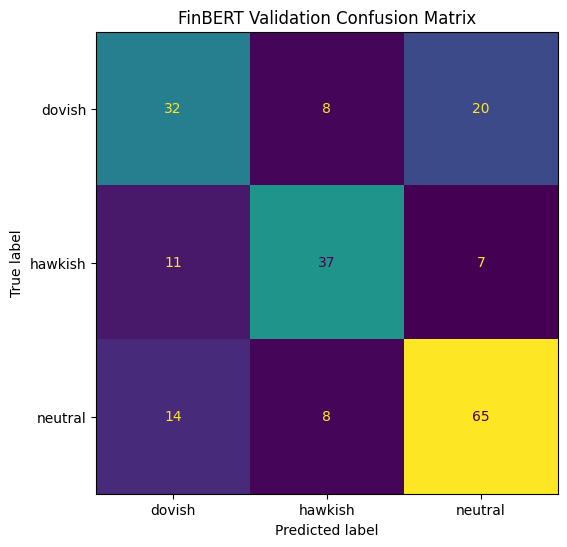

In [38]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on validation set
pred_output = trainer.predict(val_ds)
val_logits = pred_output.predictions
val_preds = np.argmax(val_logits, axis=1)

# True labels
val_labels = np.array(val_df["label"])

# Confirm your label mapping is correct
label_id_to_name = {
    0: "dovish",
    1: "hawkish",
    2: "neutral"
}

target_names = [label_id_to_name[i] for i in sorted(label_id_to_name.keys())]

# ----------------------------
# 1) Classification report
# ----------------------------
report_dict = classification_report(
    val_labels,
    val_preds,
    labels=[0, 1, 2],
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
print("Classification Report:")
display(report_df)

# Optional plain-text version
print(
    classification_report(
        val_labels,
        val_preds,
        labels=[0, 1, 2],
        target_names=target_names,
        zero_division=0
    )
)

# ----------------------------
# 2) Confusion matrix
# ----------------------------
cm = confusion_matrix(val_labels, val_preds, labels=[0, 1, 2])

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{name}" for name in target_names],
    columns=[f"pred_{name}" for name in target_names]
)

print("Confusion Matrix:")
display(cm_df)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, values_format="d", colorbar=False)
plt.title("FinBERT Validation Confusion Matrix")
plt.show()

In [39]:
report_df.to_csv("/content/finbert_classification_report.csv", index=True)
cm_df.to_csv("/content/finbert_confusion_matrix.csv", index=True)

Evaluation of FinBERT-FOMC.

In [40]:
# -------------------------------------------------
# FinBERT-FOMC configuration
# -------------------------------------------------
from transformers import BertTokenizer, BertForSequenceClassification, pipeline, AutoTokenizer, AutoModelForSequenceClassification

finbert = BertForSequenceClassification.from_pretrained('ZiweiChen/FinBERT-FOMC',num_labels=3, ignore_mismatched_sizes=True)
tokenizer = BertTokenizer.from_pretrained('ZiweiChen/FinBERT-FOMC')
finbert_fomc = pipeline("text-classification", model=finbert, tokenizer=tokenizer)

label_id_to_name = {
    0: "dovish",
    1: "hawkish",
    2: "neutral"
}

label_name_to_id = {v: k for k, v in label_id_to_name.items()}
max_length = 128

config.json:   0%|          | 0.00/810 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ZiweiChen/FinBERT-FOMC
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [41]:
def tokenize_function_fomc(examples):
    return tokenizer(
        examples["sentence"],
        truncation=True,
        max_length=max_length
    )

In [42]:
from datasets import Dataset

train_ds_fomc = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds_fomc = Dataset.from_pandas(val_df.reset_index(drop=True))

train_ds_fomc = train_ds_fomc.map(tokenize_function_fomc, batched=True)
val_ds_fomc = val_ds_fomc.map(tokenize_function_fomc, batched=True)

train_ds_fomc = train_ds_fomc.remove_columns(
    [col for col in train_ds_fomc.column_names if col not in ["input_ids", "attention_mask", "label"]]
)
val_ds_fomc = val_ds_fomc.remove_columns(
    [col for col in val_ds_fomc.column_names if col not in ["input_ids", "attention_mask", "label"]]
)

train_ds_fomc.set_format("torch")
val_ds_fomc.set_format("torch")

Map:   0%|          | 0/808 [00:00<?, ? examples/s]

Map:   0%|          | 0/202 [00:00<?, ? examples/s]

In [43]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }

In [44]:
from transformers import TrainingArguments

training_args_fomc = TrainingArguments(
    output_dir="/content/finbert_fomc_stance_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none"
)

In [45]:
from transformers import Trainer, DataCollatorWithPadding, EarlyStoppingCallback

data_collator_fomc = DataCollatorWithPadding(tokenizer=tokenizer)

trainer_fomc = Trainer(
    model=finbert,
    args=training_args_fomc,
    train_dataset=train_ds_fomc,
    eval_dataset=val_ds_fomc,
    data_collator=data_collator_fomc,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [46]:
trainer_fomc.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.434055,1.065034,0.460396,0.333884,0.367834
2,0.976513,0.945477,0.544554,0.506369,0.519455
3,0.767462,0.872340,0.613861,0.592342,0.603480
4,0.508075,0.956494,0.594059,0.573843,0.581877
5,0.345150,0.984140,0.613861,0.602221,0.610725
6,0.221142,1.091207,0.628713,0.623463,0.628961
7,0.140836,1.209174,0.608911,0.601000,0.607181
8,0.107434,1.218771,0.623762,0.619326,0.624092


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=408, training_loss=0.5625835177945155, metrics={'train_runtime': 6044.8249, 'train_samples_per_second': 1.069, 'train_steps_per_second': 0.067, 'total_flos': 251688539792592.0, 'train_loss': 0.5625835177945155, 'epoch': 8.0})

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


FinBERT-FOMC Classification Report:


,precision,recall,f1-score,support
dovish,0.555556,0.583333,0.569106,60.000000
hawkish,0.673469,0.600000,0.634615,55.000000
neutral,0.655556,0.678161,0.666667,87.000000
accuracy,0.628713,0.628713,0.628713,0.628713
macro avg,0.628193,0.620498,0.623463,202.000000
weighted avg,0.630730,0.628713,0.628961,202.000000


              precision    recall  f1-score   support

      dovish       0.56      0.58      0.57        60
     hawkish       0.67      0.60      0.63        55
     neutral       0.66      0.68      0.67        87

    accuracy                           0.63       202
   macro avg       0.63      0.62      0.62       202
weighted avg       0.63      0.63      0.63       202

FinBERT-FOMC Confusion Matrix:


,pred_dovish,pred_hawkish,pred_neutral
true_dovish,35,4,21
true_hawkish,12,33,10
true_neutral,16,12,59


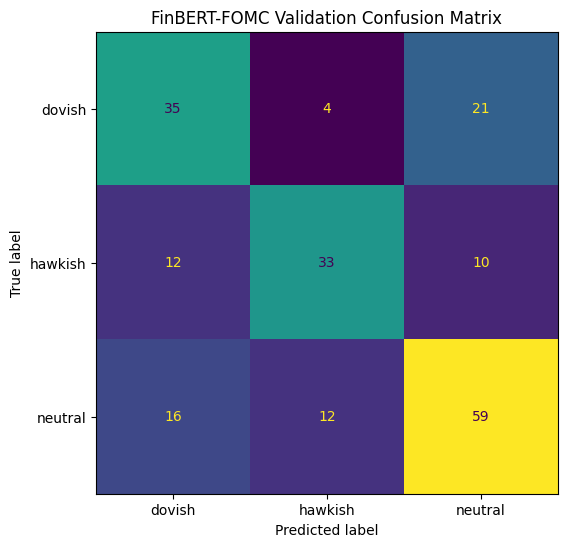

In [47]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

pred_output_fomc = trainer_fomc.predict(val_ds_fomc)
val_logits_fomc = pred_output_fomc.predictions
val_preds_fomc = np.argmax(val_logits_fomc, axis=1)
val_labels_fomc = np.array(val_df["label"])

target_names = [label_id_to_name[i] for i in sorted(label_id_to_name.keys())]

report_dict_fomc = classification_report(
    val_labels_fomc,
    val_preds_fomc,
    labels=[0, 1, 2],
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

report_df_fomc = pd.DataFrame(report_dict_fomc).transpose()
print("FinBERT-FOMC Classification Report:")
display(report_df_fomc)

print(
    classification_report(
        val_labels_fomc,
        val_preds_fomc,
        labels=[0, 1, 2],
        target_names=target_names,
        zero_division=0
    )
)

cm_fomc = confusion_matrix(val_labels_fomc, val_preds_fomc, labels=[0, 1, 2])

cm_df_fomc = pd.DataFrame(
    cm_fomc,
    index=[f"true_{name}" for name in target_names],
    columns=[f"pred_{name}" for name in target_names]
)

print("FinBERT-FOMC Confusion Matrix:")
display(cm_df_fomc)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_fomc, display_labels=target_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, values_format="d", colorbar=False)
plt.title("FinBERT-FOMC Validation Confusion Matrix")
plt.show()